In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split

In [3]:
df=pd.read_csv('lung_cancer.csv')
df

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,F,56,1,1,1,2,2,2,1,1,2,2,2,2,1,YES
305,M,70,2,1,1,1,1,2,2,2,2,2,2,1,2,YES
306,M,58,2,1,1,1,1,1,2,2,2,2,1,1,2,YES
307,M,67,2,1,2,1,1,2,2,1,2,2,2,1,2,YES


### Checking Missing Values

In [4]:
df.isnull().sum()

GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL CONSUMING        0
COUGHING                 0
SHORTNESS OF BREATH      0
SWALLOWING DIFFICULTY    0
CHEST PAIN               0
LUNG_CANCER              0
dtype: int64

### There are no Missing Values in the Dataset

### Checking the basic information about the Dataset

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 309 non-null    object
 1   AGE                    309 non-null    int64 
 2   SMOKING                309 non-null    int64 
 3   YELLOW_FINGERS         309 non-null    int64 
 4   ANXIETY                309 non-null    int64 
 5   PEER_PRESSURE          309 non-null    int64 
 6   CHRONIC DISEASE        309 non-null    int64 
 7   FATIGUE                309 non-null    int64 
 8   ALLERGY                309 non-null    int64 
 9   WHEEZING               309 non-null    int64 
 10  ALCOHOL CONSUMING      309 non-null    int64 
 11  COUGHING               309 non-null    int64 
 12  SHORTNESS OF BREATH    309 non-null    int64 
 13  SWALLOWING DIFFICULTY  309 non-null    int64 
 14  CHEST PAIN             309 non-null    int64 
 15  LUNG_CANCER            

### Performing Train Test Split

In [6]:
X_train,X_test,y_train,y_test=train_test_split(df.drop(columns=['LUNG_CANCER'],axis=1),
                                               df['LUNG_CANCER'],
                                               test_size=0.3,
                                               random_state=42
)

In [7]:
X_train

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN
298,M,62,2,1,2,1,1,2,1,2,2,2,2,1,2
287,F,51,2,2,2,2,1,2,1,1,1,1,2,2,1
72,M,67,1,1,1,1,2,2,2,2,2,2,2,1,2
15,F,48,1,2,2,2,2,2,2,2,1,2,2,2,1
10,F,61,2,2,2,2,2,2,1,2,1,2,2,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,M,65,2,2,2,2,2,1,1,1,1,1,1,1,1
71,F,66,2,2,2,2,1,2,1,2,1,2,2,2,1
106,F,61,2,2,2,2,2,2,1,1,1,1,2,2,1
270,F,70,2,1,1,1,1,2,1,1,1,1,2,1,1


### Checking the Outliers in the Training Dataset

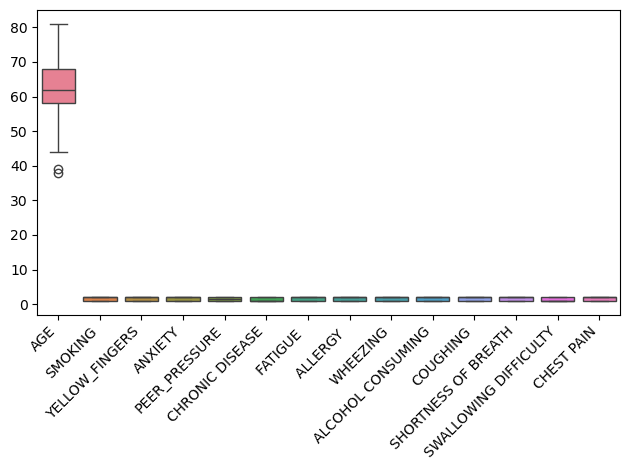

In [8]:
X_train_numeric=X_train.select_dtypes(include='number')
sns.boxplot(X_train_numeric)
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()

### From the above boxplot we get to know that outliers are there only in Age Column
- The AGE feature showed a few extreme values in the boxplot; however, these values were not capped or removed because they represent valid and realistic human ages. Age is a medically significant factor in lung cancer prediction, and higher or lower age values carry meaningful information rather than noise

### Performing EDA

C:\Users\Dell\AppData\Local\Temp\ipykernel_16480\1813547204.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(x='LUNG_CANCER',data=df,palette='dark')


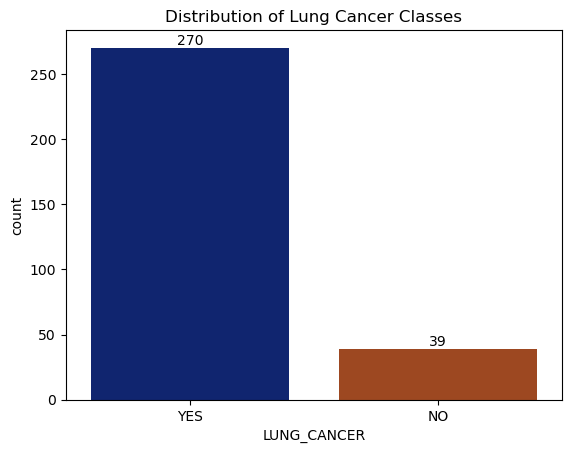

In [9]:
# Plotting Countplot for target variable
ax=sns.countplot(x='LUNG_CANCER',data=df,palette='dark')
plt.title('Distribution of Lung Cancer Classes')

for bars in ax.containers:
    ax.bar_label(bars)

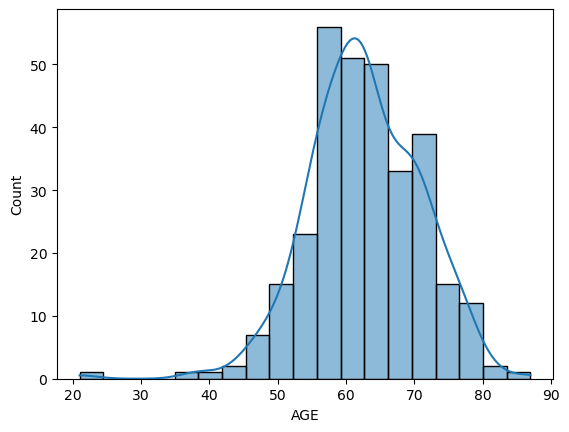

In [10]:
sns.histplot(df['AGE'], kde=True)
plt.show()

### The AGE distribution is approximately normal with a peak around 55–65 years

### Plotting CountPlot for all Categorical Variable

C:\Users\Dell\AppData\Local\Temp\ipykernel_16480\1354268753.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df[col].map(label_map), data=df, palette='dark')


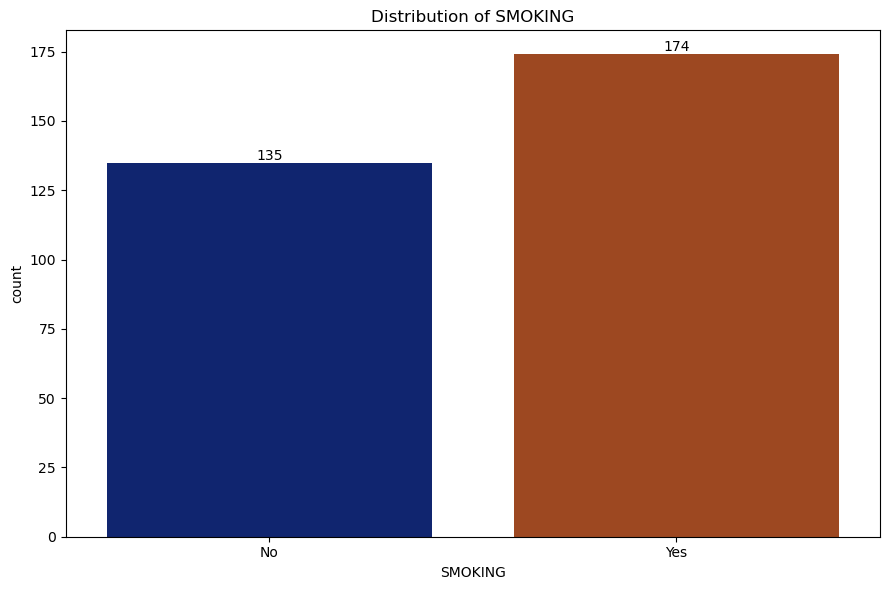

C:\Users\Dell\AppData\Local\Temp\ipykernel_16480\1354268753.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df[col].map(label_map), data=df, palette='dark')


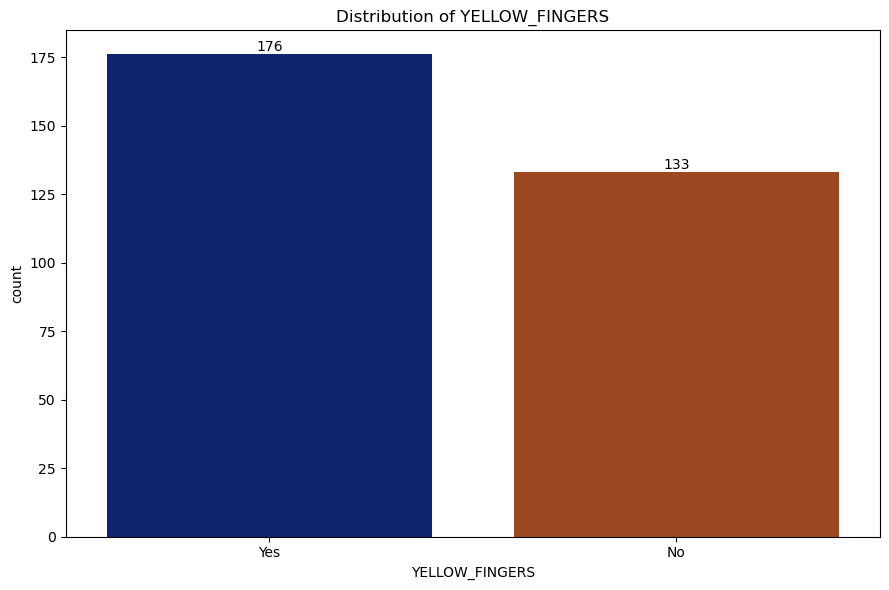

C:\Users\Dell\AppData\Local\Temp\ipykernel_16480\1354268753.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df[col].map(label_map), data=df, palette='dark')


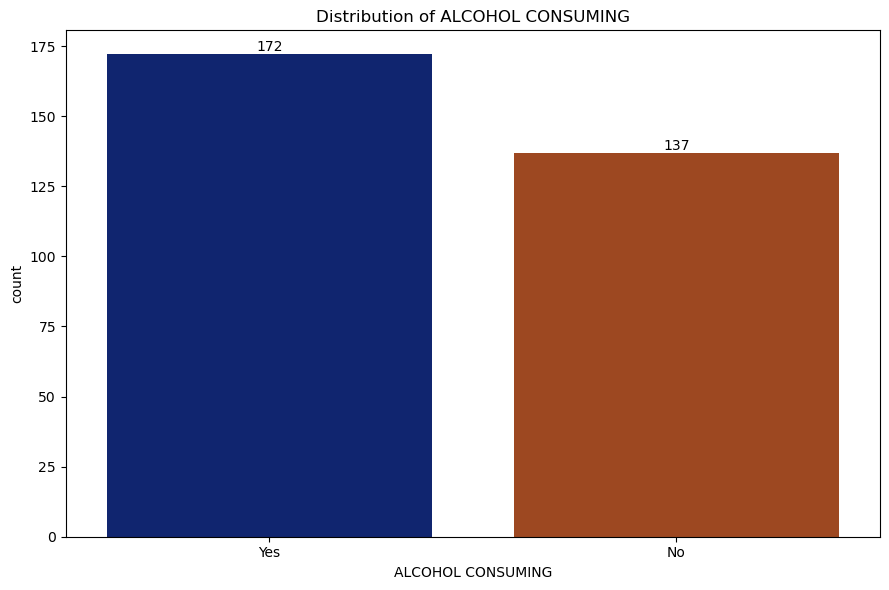

C:\Users\Dell\AppData\Local\Temp\ipykernel_16480\1354268753.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df[col].map(label_map), data=df, palette='dark')


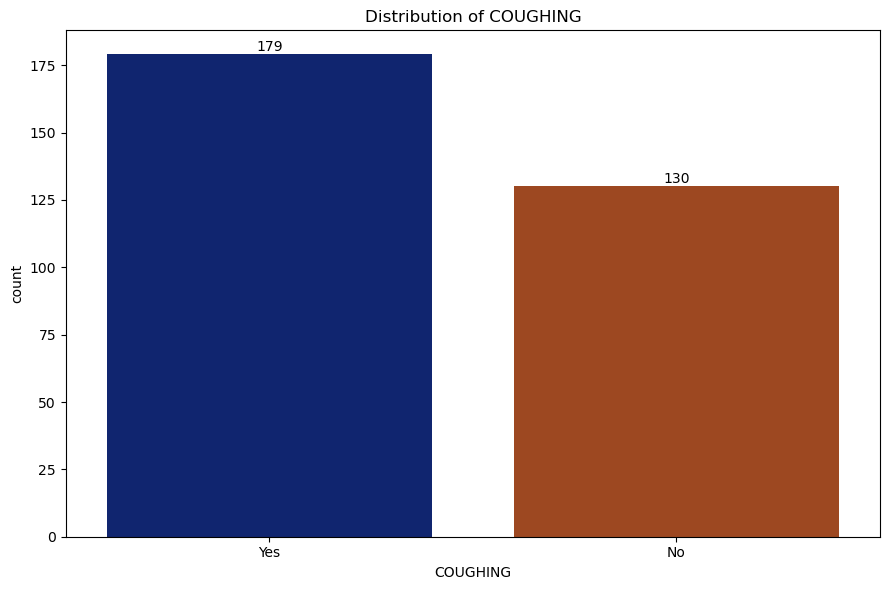

C:\Users\Dell\AppData\Local\Temp\ipykernel_16480\1354268753.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df[col].map(label_map), data=df, palette='dark')


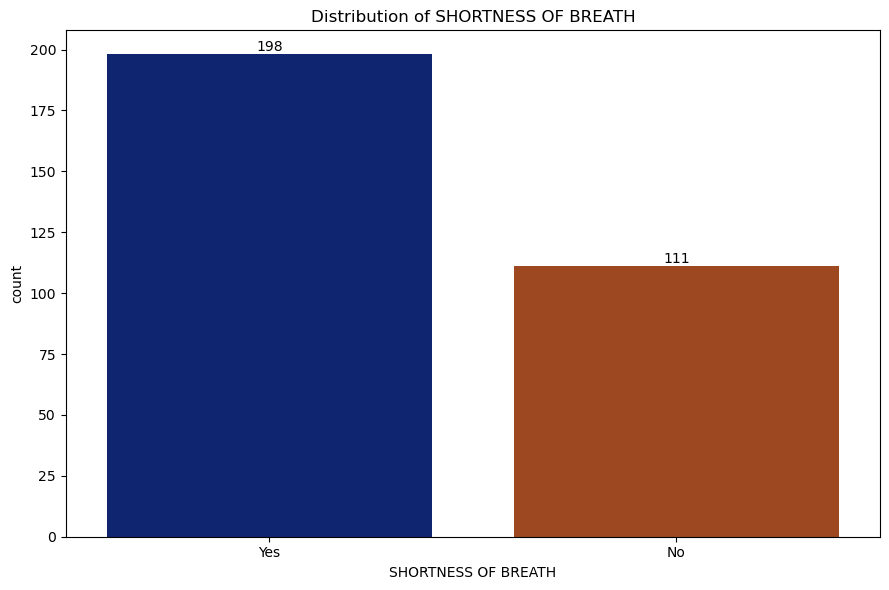

C:\Users\Dell\AppData\Local\Temp\ipykernel_16480\1354268753.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df[col].map(label_map), data=df, palette='dark')


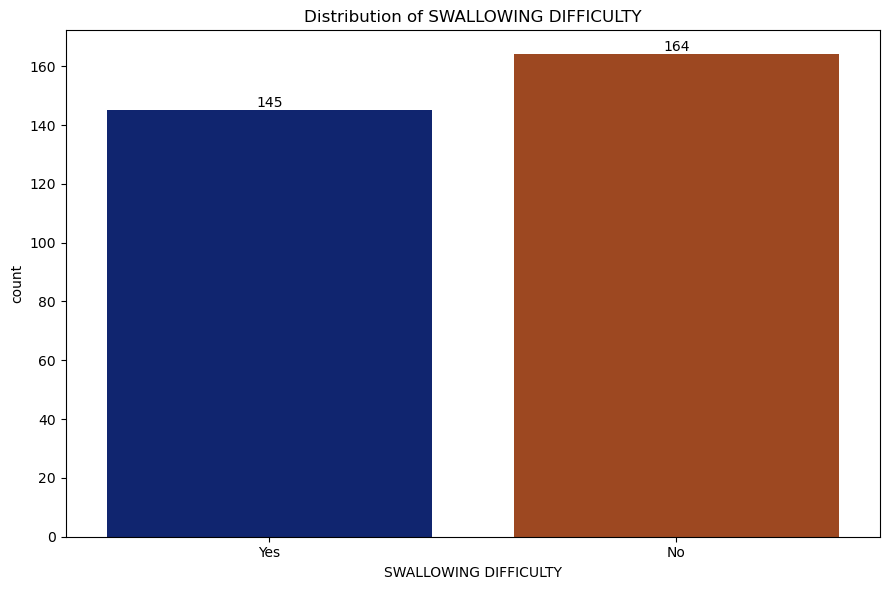

C:\Users\Dell\AppData\Local\Temp\ipykernel_16480\1354268753.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df[col].map(label_map), data=df, palette='dark')


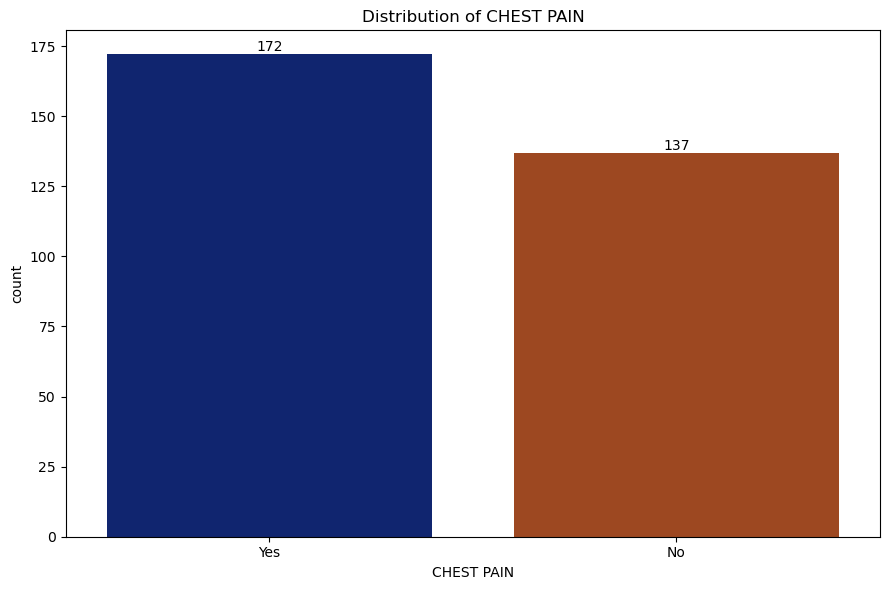

In [11]:
count = [
    'SMOKING',
    'YELLOW_FINGERS',
    'ALCOHOL CONSUMING',
    'COUGHING',
    'SHORTNESS OF BREATH',
    'SWALLOWING DIFFICULTY',
    'CHEST PAIN'
]

label_map={1:'No',2:'Yes'}

for col in count:
    plt.figure(figsize=(9, 6))
    ax = sns.countplot(x=df[col].map(label_map), data=df, palette='dark')
    plt.title(f'Distribution of {col}')
    
    for container in ax.containers:
        ax.bar_label(container)
    
    plt.tight_layout()
    plt.show()


### Plotting Age vs Lung_Cancer

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

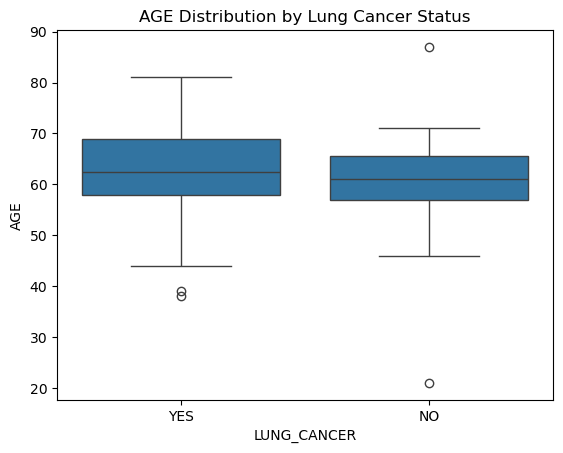

<Figure size 1500x400 with 0 Axes>

In [12]:
ax=sns.boxplot(x='LUNG_CANCER', y='AGE', data=df)
plt.title('AGE Distribution by Lung Cancer Status')
plt.figure(figsize=(15,4))
plt.tight_layout

1. The median age for LungCancer=Yes is slighter Higher than LungCancer=No.So LungCancerPatients are margianlaly older than Non-LungCancerPatients.
2. Spread=The Yes[Cancer] patients has a wider box as compared to No.This means Age variability is higher among lung cancer patients.
3. Range of Ages= Yes[Cancer]=45 to 82 and No[Cancer]=47 to71
- The Yes[Cancer] patients are extended slighlty higher in Ages as compared to No[Cancer] patients

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

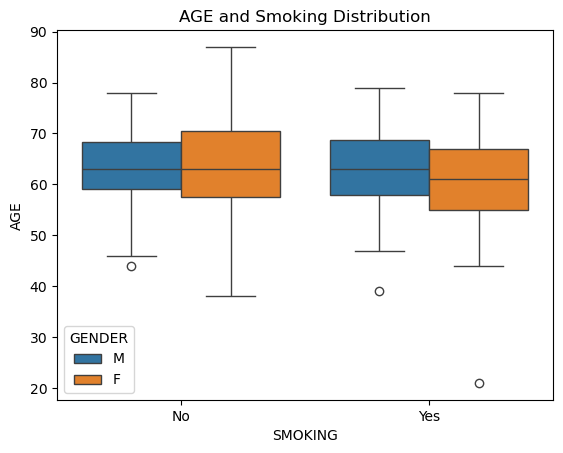

<Figure size 1500x400 with 0 Axes>

In [13]:
label_map={1:'No',2:'Yes'}
ax=sns.boxplot(x=df['SMOKING'].map(label_map), y='AGE',hue='GENDER',data=df)
plt.title('AGE and Smoking Distribution')
plt.figure(figsize=(15,4))
plt.tight_layout

- The Median Age of Not-Smoking for both M and f is 62-65 and The Median Age of Smoking for M is slighter higher than F means the Median Age of Smoking is slightly higher than Not-Smoking.

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

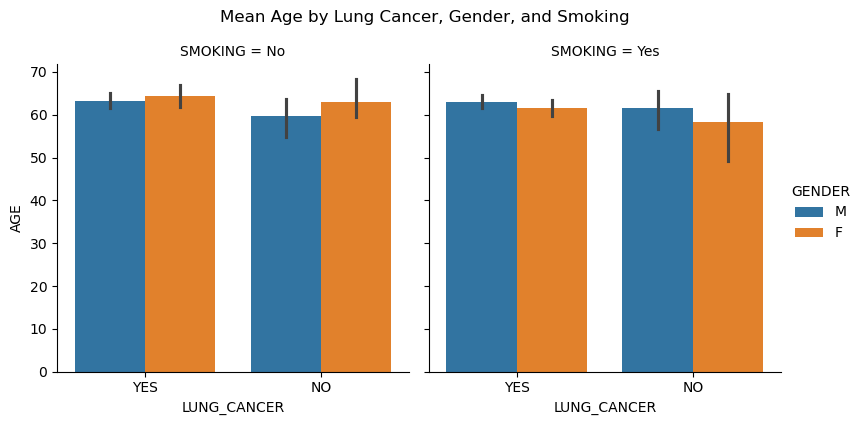

<Figure size 1500x400 with 0 Axes>

In [14]:
sns.catplot(
    x='LUNG_CANCER',
    y='AGE',
    hue='GENDER',
    col=df['SMOKING'].map(label_map),
    data=df,
    kind='bar',
    height=4,
    aspect=1)
plt.suptitle('Mean Age by Lung Cancer, Gender, and Smoking', y=1.05)
plt.figure(figsize=(15,4))
plt.tight_layout

1. The Mean Age of Males that Donot Smoke and has Lungcancer is slightly lower than Females.
2. The Mean Age of Males that Donot Smoke and donot have Lungcancer is slightly lower than Females.
3. The Mean Age of Males that Smoke and has Lungcancer is slightly higher than Females.
4. The Mean Age of Males that Smoke and donot have Lungcancer is slightly higher than Females.
- The plot shows that lung cancer patients tend to be older across both genders and smoking statuses.But alone age and smoking cannot explain lungcancer risk.

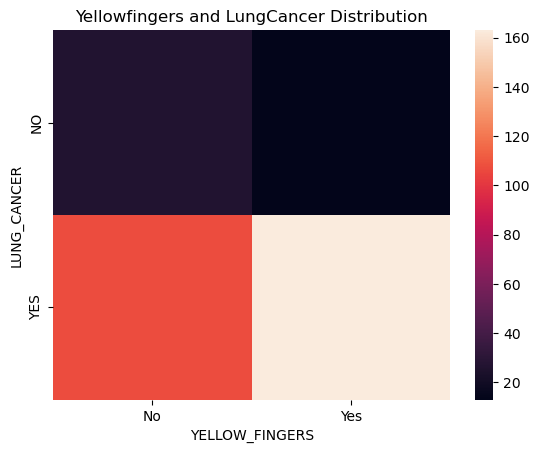

<Figure size 1400x1000 with 0 Axes>

In [32]:
#Plotting Yellowfingers vs LungCancer
sns.heatmap(pd.crosstab(df['LUNG_CANCER'],df['YELLOW_FINGERS'].map(label_map)))
plt.title('Yellowfingers and LungCancer Distribution')
plt.figure(figsize=(14,10))
plt.show()

1. This Heatmap shows higher no.of patients have yellow_fingers when they have lung cancer and very less patient that dont have their fingers yellow when they have cancer.
2. There are moderate patients who dont have yellow_fingers when they have lung_cancer.
- So it shows a strong relation btwn lung_cancer and Yellowfingers

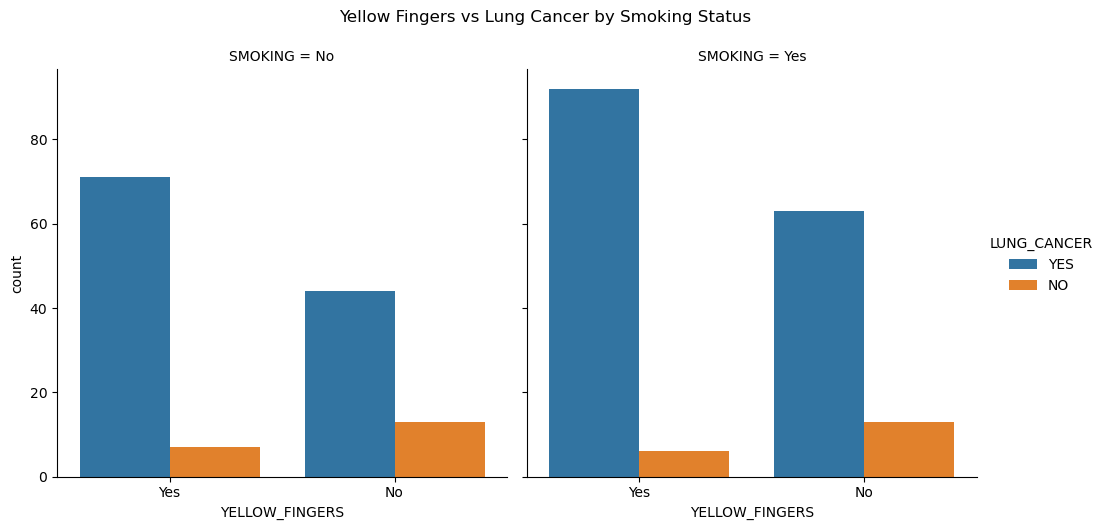

In [50]:
df_plot=df.copy()

label_map={1: 'No', 2: 'Yes'}

df_plot['YELLOW_FINGERS'] = df_plot['YELLOW_FINGERS'].replace(label_map)
df_plot['LUNG_CANCER'] = df_plot['LUNG_CANCER'].replace(label_map)
df_plot['SMOKING'] = df_plot['SMOKING'].replace(label_map)

sns.catplot(
    data=df_plot,
    x='YELLOW_FINGERS',    
    hue='LUNG_CANCER',     
    col='SMOKING',          
    kind='count'
)

plt.suptitle('Yellow Fingers vs Lung Cancer by Smoking Status',y=1.05)
plt.show()


- This shows that their are higher number of patients with lungcancer that has yellow_fingers and smokes as compared to patients that dontSmoke + dont have YellowFingers

<Figure size 1400x1000 with 0 Axes>

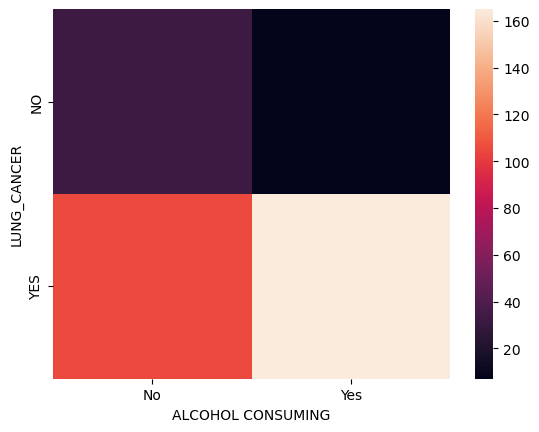

<Figure size 1400x1000 with 0 Axes>

In [56]:
# LungCancer vs Alcohol
sns.heatmap(pd.crosstab(df['LUNG_CANCER'],df['ALCOHOL CONSUMING'].map(label_map)))
plt.figure(figsize=(14,10))

- From this it clearly shows that there are higher no.of patients that were diagnoised with lung_cancer, consumes Alcohol.At the same time there are moderate patients that has lung_cancer but doesnot consumes Alcohol and least no.of patients that do not have lung_cancer and donot consumes Alcohol
- So it shows a strong relation btwn lung_cancer and alcohol consumption

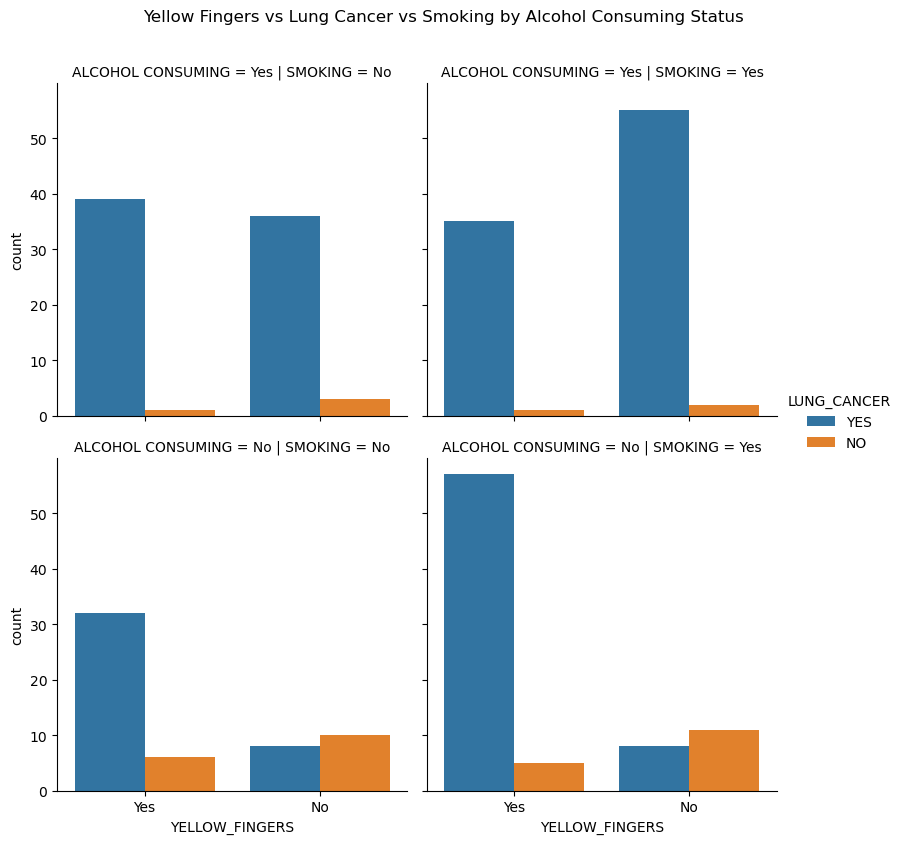

In [67]:
df_plot=df.copy()

label_map={1: 'No', 2: 'Yes'}

df_plot['YELLOW_FINGERS'] = df_plot['YELLOW_FINGERS'].replace(label_map)
df_plot['LUNG_CANCER'] = df_plot['LUNG_CANCER'].replace(label_map)
df_plot['SMOKING'] = df_plot['SMOKING'].replace(label_map)
df_plot['ALCOHOL CONSUMING'] = df_plot['ALCOHOL CONSUMING'].replace(label_map)


sns.catplot(
    data=df_plot,
    x='YELLOW_FINGERS',    
    hue='LUNG_CANCER',     
    col='SMOKING',
    row='ALCOHOL CONSUMING',
    kind='count',
    height=4,
    aspect=1
)

plt.suptitle('Yellow Fingers vs Lung Cancer vs Smoking by Alcohol Consuming Status',y=1.05)
plt.show()
